In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Data_Bayes.csv")

In [3]:
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

In [4]:
X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].values

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
classes = np.unique(y_train)

data = {}

for c in classes:
    data[c] = X_train[y_train == c]

print(data.keys())

dict_keys([np.int64(0), np.int64(1)])


In [7]:
priors = {}

for c in classes:

    priors[c] = len(data[c]) / len(X_train)

priors

{np.int64(0): 0.6263736263736264, np.int64(1): 0.37362637362637363}

In [8]:
means = {}

for c in classes:

    means[c] = np.mean(data[c], axis=0)

means[0][:5]

array([1.21554912e+01, 1.80486316e+01, 7.81044912e+01, 4.63856842e+02,
       9.17031228e-02])

In [9]:
variances = {}

for c in classes:

    variances[c] = np.var(data[c], axis=0)

variances[0][:5]

array([3.16543424e+00, 1.54853809e+01, 1.39652580e+02, 1.81236865e+04,
       1.78242071e-04])

In [10]:
def gaussian_pdf(x, mean, var):

    epsilon = 1e-9

    coefficient = 1 / np.sqrt(2 * np.pi * (var + epsilon))

    exponent = np.exp(

        -((x - mean) ** 2) /

        (2 * (var + epsilon))

    )

    return coefficient * exponent

In [11]:
sample = X_test[0]

prob = gaussian_pdf(
    sample,
    means[0],
    variances[0]
)

print(prob[:5])

[2.05385012e-01 1.87593616e-02 3.11235075e-02 2.67823949e-03
 2.95392065e+01]


In [12]:
def posterior(sample):

    posteriors = {}

    for c in classes:

        prior = np.log(priors[c])

        likelihood = np.sum(

            np.log(

                gaussian_pdf(
                    sample,
                    means[c],
                    variances[c]
                )

            )

        )

        posteriors[c] = prior + likelihood

    return posteriors

In [13]:
sample = X_test[0]

result = posterior(sample)

print(result)

{np.int64(0): np.float64(16.233981072110456), np.int64(1): np.float64(-19.650001697950117)}


In [14]:
prediction = max(result, key=result.get)

print(prediction)

0


In [15]:
predictions = []

for sample in X_test:

    result = posterior(sample)

    predictions.append(

        max(result, key=result.get)

    )

predictions = np.array(predictions)

In [16]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Scratch Accuracy :", accuracy)

Scratch Accuracy : 0.9210526315789473


In [17]:
model = GaussianNB()

model.fit(X_train, y_train)

sk_pred = model.predict(X_test)

print("Scratch Accuracy :", accuracy_score(y_test, predictions))

print("Sklearn Accuracy :", accuracy_score(y_test, sk_pred))

Scratch Accuracy : 0.9210526315789473
Sklearn Accuracy : 0.9385964912280702


In [18]:
comparison = pd.DataFrame({

    "Model":[
        "Scratch Gaussian NB",
        "Scikit-learn Gaussian NB"
    ],

    "Accuracy":[
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, sk_pred)
    ]

})

comparison

,Model,Accuracy
0,Scratch Gaussian NB,0.921053
1,Scikit-learn Gaussian NB,0.938596


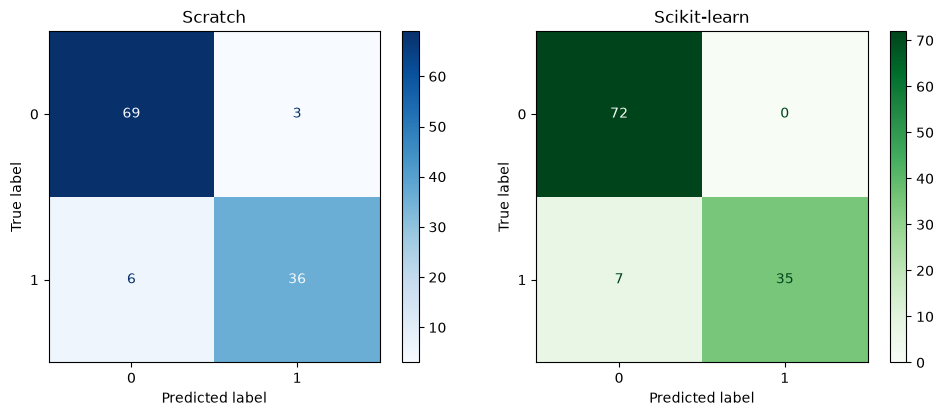

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Scratch")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    sk_pred,
    ax=axes[1],
    cmap="Greens"
)
axes[1].set_title("Scikit-learn")

plt.tight_layout()
plt.show()

<Axes: xlabel='Model'>

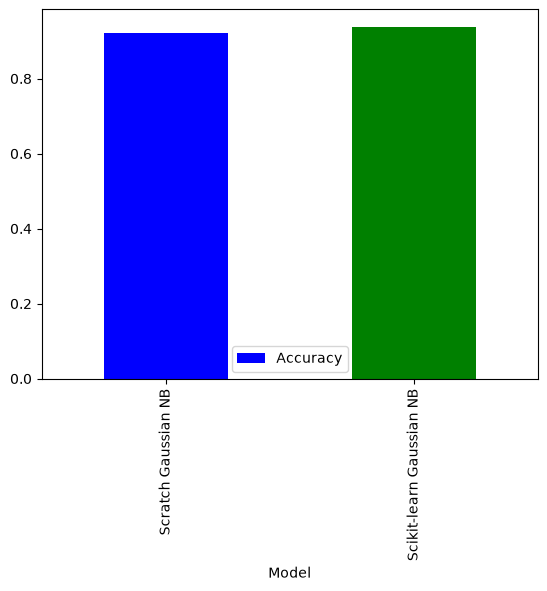

In [28]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    color=["blue","green"]
)

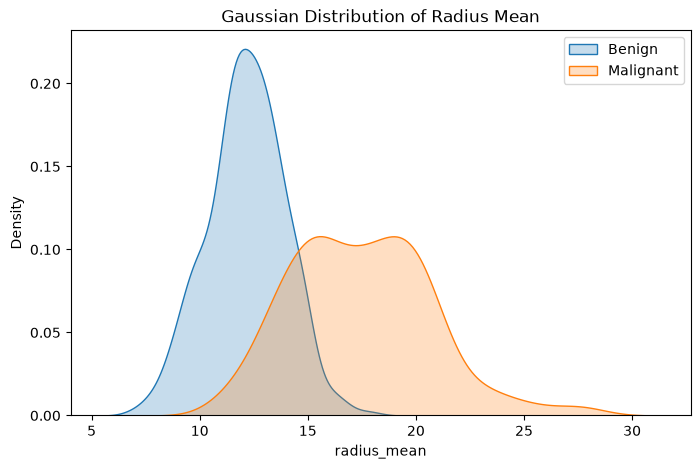

In [21]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df[df["diagnosis"]==0]["radius_mean"],
    fill=True,
    label="Benign"
)

sns.kdeplot(
    df[df["diagnosis"]==1]["radius_mean"],
    fill=True,
    label="Malignant"
)

plt.legend()

plt.title("Gaussian Distribution of Radius Mean")

plt.show()